In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

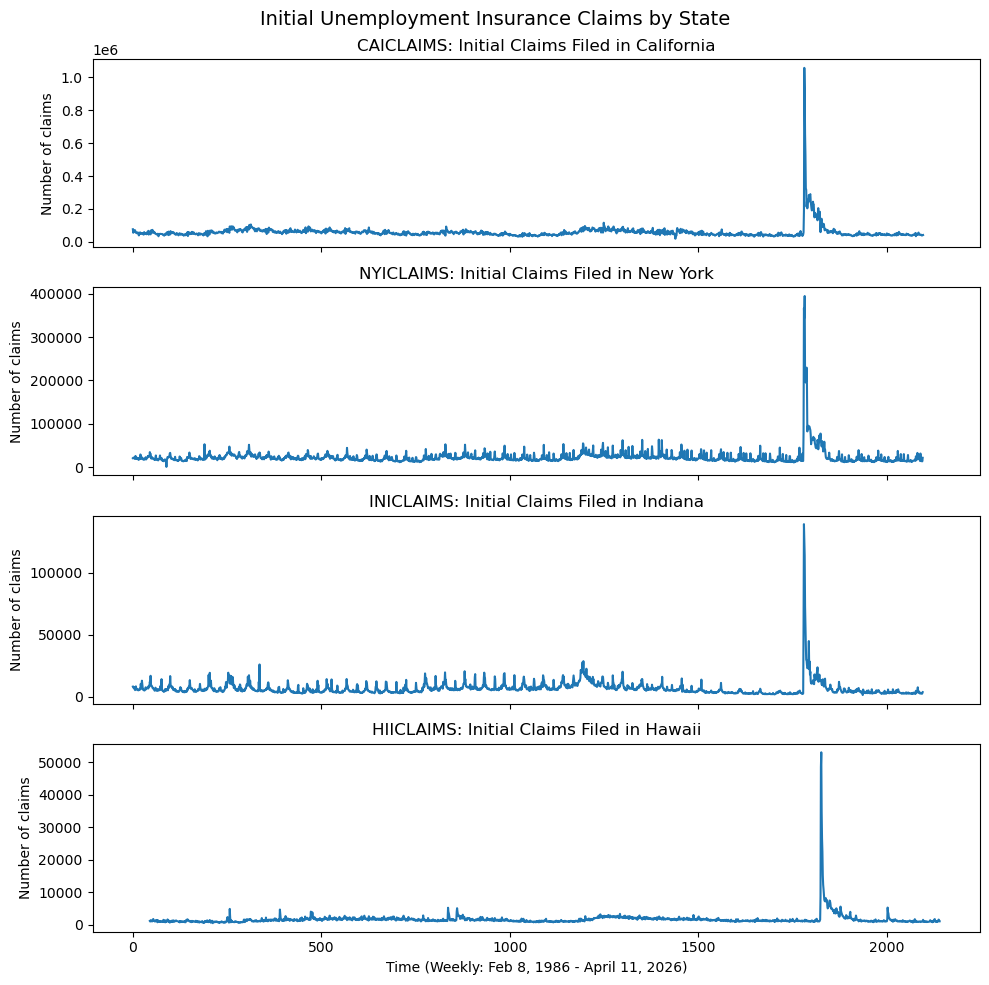

In [2]:
datasets = ["CAICLAIMS", "NYICLAIMS", "INICLAIMS", "HIICLAIMS"]
state_names = {
    "CAICLAIMS": "California",
    "NYICLAIMS": "New York",
    "INICLAIMS": "Indiana",
    "HIICLAIMS": "Hawaii"
}

claims_dfs = {}

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for ax, code in zip(axes, datasets):
    df = pd.read_csv(f"Data/{code}.csv")
    df.rename(columns={code: "Claims"}, inplace=True)
    
    claims_dfs[code] = df
    globals()[code] = df
    
    ax.plot(df["Claims"])
    ax.set_title(f"{code}: Initial Claims Filed in {state_names[code]}")
    ax.set_ylabel("Number of claims")

axes[-1].set_xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
fig.suptitle("Initial Unemployment Insurance Claims by State", fontsize=14)
plt.tight_layout()
plt.show();

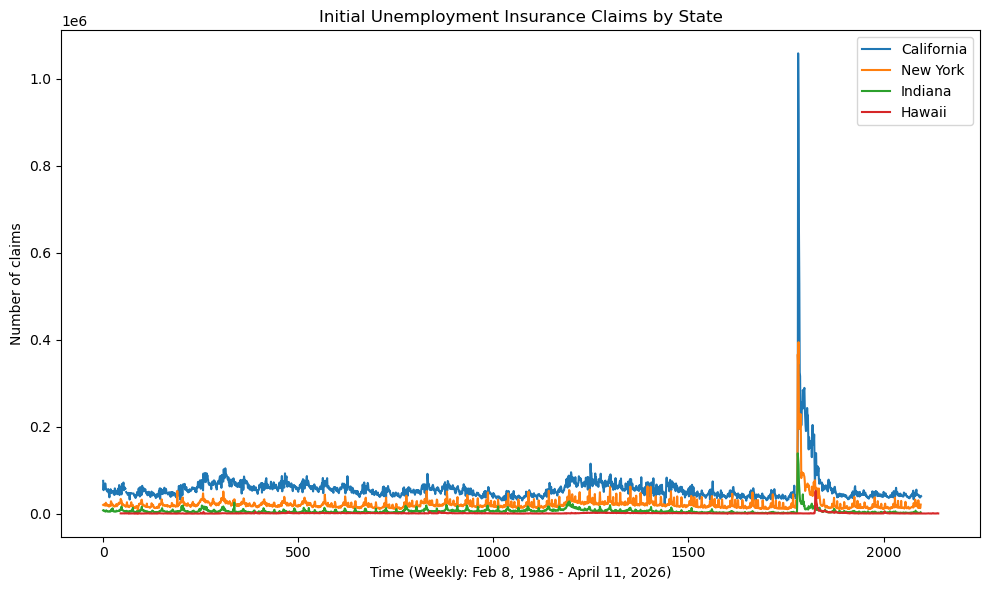

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Claims"], label=state_names[code])

ax.set_xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
ax.set_ylabel("Number of claims")
ax.set_title("Initial Unemployment Insurance Claims by State")
ax.legend()
plt.tight_layout()
plt.show();

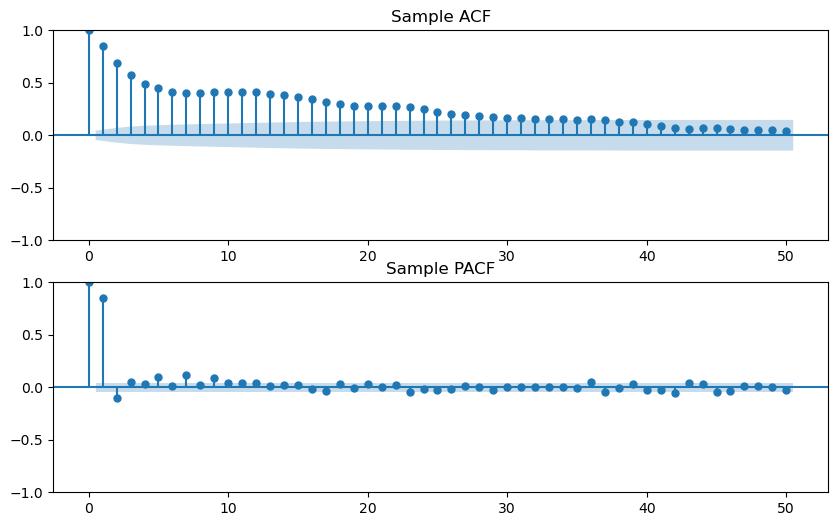

In [4]:
y_CA = claims_dfs["CAICLAIMS"]["Claims"]

ttrain = np.arange(1900)
ttest = np.arange(1900, len(y_CA))
ytrain_CA = y_CA[:1900]
ytest_CA = y_CA[1900:]

p_max = 50
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.show();

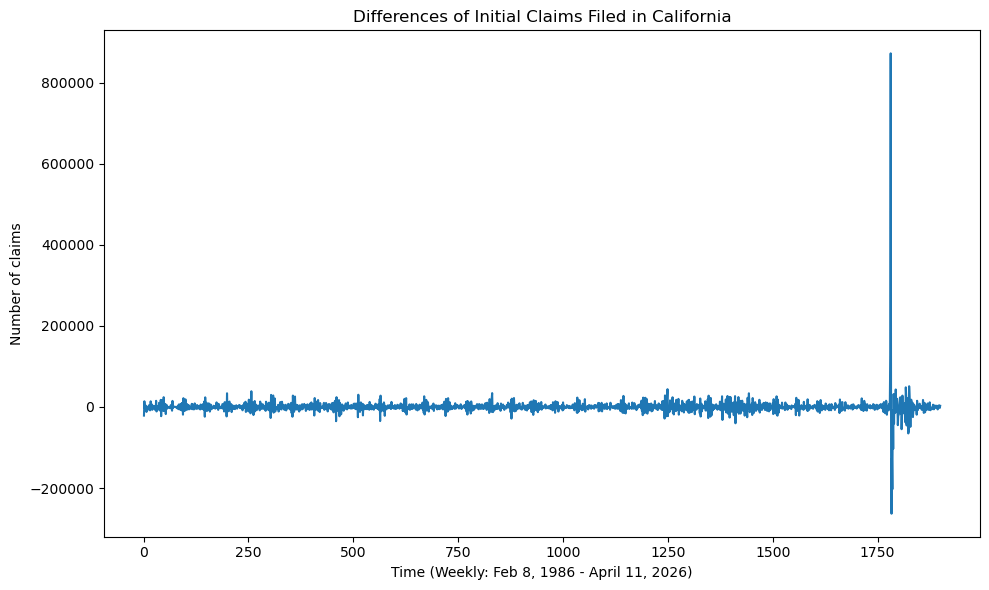

In [5]:
ytrain_CA_diff = ytrain_CA.diff()

plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

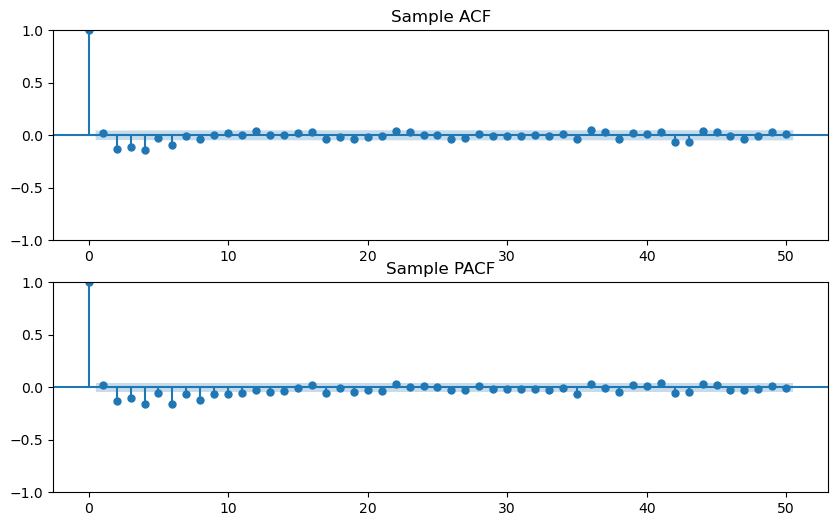

In [6]:
p_max = 50
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.show();

In [15]:
pmax, dmax, qmax = 8, 1, 6

def fit_arima(params):
    warnings.filterwarnings("ignore")
    p, d, q = params
    
    try:
        model = ARIMA(ytrain_CA, order=(p, d, q)).fit()
        forecast = model.get_forecast(steps=len(ytest_CA))
        yhat = forecast.predicted_mean
        yhat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, yhat))
        
        return {
            "p": p,
            "d": d,
            "q": q,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": rmse
        }
    except Exception:
        return None

In [16]:
import itertools
from joblib import Parallel, delayed

pvals = range(pmax + 1)
dvals = range(dmax + 1)
qvals = range(qmax + 1)

param_grid = list(itertools.product(pvals, dvals, qvals))

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(fit_arima)(params) for params in param_grid
)

# remove failed fits
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   16.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   45.2s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 124 out of 126 | elapsed:  1.4min remaining:    1.3s
[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed:  1.4min finished


In [17]:
best_aic = results_df.loc[results_df["AIC"].idxmin()]
best_bic = results_df.loc[results_df["BIC"].idxmin()]
best_rmse = results_df.loc[results_df["RMSE"].idxmin()]

print(
    f"Best model by AIC: ARIMA({int(best_aic['p'])}, "
    f"{int(best_aic['d'])}, {int(best_aic['q'])}), "
    f"AIC: {best_aic['AIC']:.3f}, ",
    f"BIC: {best_aic['BIC']:.3f}, ",
    f"RMSE: {best_aic['RMSE']:.3f}"
)
print(
    f"Best model by BIC: ARIMA({int(best_bic['p'])}, "
    f"{int(best_bic['d'])}, {int(best_bic['q'])}), "
    f"AIC: {best_bic['AIC']:.3f}, ",
    f"BIC: {best_bic['BIC']:.3f}, ",
    f"RMSE: {best_bic['RMSE']:.3f}"
)
print(
    f"Best model by RMSE: ARIMA({int(best_rmse['p'])}, "
    f"{int(best_rmse['d'])}, {int(best_rmse['q'])}), "
    f"AIC: {best_rmse['AIC']:.3f}, ",
    f"BIC: {best_rmse['BIC']:.3f}, ",
    f"RMSE: {best_rmse['RMSE']:.3f}"
)

Best model by AIC: ARIMA(3, 1, 5), AIC: 43396.703,  BIC: 43446.644,  RMSE: 5527.407
Best model by BIC: ARIMA(0, 1, 6), AIC: 43397.590,  BIC: 43436.434,  RMSE: 5335.297
Best model by RMSE: ARIMA(6, 1, 0), AIC: 43459.670,  BIC: 43498.514,  RMSE: 4974.708


In [19]:
best_aic_model = ARIMA(ytrain_CA, order=(best_aic['p'], best_aic['d'], best_aic['q'])).fit()
print(best_aic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1900
Model:                 ARIMA(3, 1, 5)   Log Likelihood              -21689.356
Date:                Fri, 24 Apr 2026   AIC                          43396.712
Time:                        19:44:45   BIC                          43446.654
Sample:                             0   HQIC                         43415.098
                               - 1900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2485      0.067    -18.628      0.000      -1.380      -1.117
ar.L2          0.1567      0.101      1.548      0.122      -0.042       0.355
ar.L3          0.4674      0.056      8.365      0.0

In [20]:
best_bic_model = ARIMA(ytrain_CA, order=(best_bic['p'], best_bic['d'], best_bic['q'])).fit()
print(best_bic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1900
Model:                 ARIMA(0, 1, 6)   Log Likelihood              -21691.795
Date:                Fri, 24 Apr 2026   AIC                          43397.590
Time:                        19:44:45   BIC                          43436.434
Sample:                             0   HQIC                         43411.890
                               - 1900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0632      0.005    -12.338      0.000      -0.073      -0.053
ma.L2         -0.2222      0.013    -16.991      0.000      -0.248      -0.197
ma.L3         -0.1541      0.030     -5.160      0.0

In [21]:
best_rmse_model = ARIMA(ytrain_CA, order=(best_rmse['p'], best_rmse['d'], best_rmse['q'])).fit()
print(best_rmse_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1900
Model:                 ARIMA(6, 1, 0)   Log Likelihood              -21722.835
Date:                Fri, 24 Apr 2026   AIC                          43459.670
Time:                        19:44:46   BIC                          43498.514
Sample:                             0   HQIC                         43473.970
                               - 1900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0243      0.004     -6.190      0.000      -0.032      -0.017
ar.L2         -0.1780      0.007    -24.848      0.000      -0.192      -0.164
ar.L3         -0.1287      0.021     -6.126      0.0

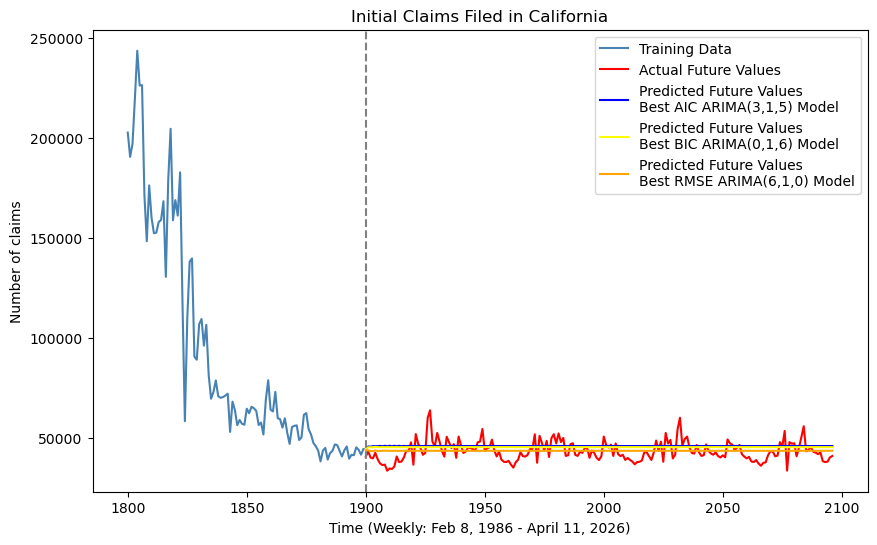

Mean Squared Error of Best AIC ARMIA(3, 1, 5) Model: 30839171.749275498
Mean Squared Error of Best BIC ARMIA(0, 1, 6) Model: 28465395.442950398
Mean Squared Error of Best RMSE ARMIA(6, 1, 0) Model: 24747717.192713093


In [26]:
best_aic_fcast = best_aic_model.get_prediction(start=1900, end=len(y_CA)-1)
best_aic_yhat = best_aic_fcast.predicted_mean
best_aic_mse = np.mean((ytest_CA - best_aic_yhat) ** 2)

best_bic_fcast = best_bic_model.get_prediction(start=1900, end=len(y_CA)-1)
best_bic_yhat = best_bic_fcast.predicted_mean
best_bic_mse = np.mean((ytest_CA - best_bic_yhat) ** 2)

best_rmse_fcast = best_rmse_model.get_prediction(start=1900, end=len(y_CA)-1)
best_rmse_yhat = best_rmse_fcast.predicted_mean
best_rmse_mse = np.mean((ytest_CA - best_rmse_yhat) ** 2)


plt.figure(figsize=(10,6))
plt.plot(ttrain[1800:], ytrain_CA[1800:], color="steelblue", label="Training Data")
plt.plot(ttest, ytest_CA, color="red", label="Actual Future Values")
plt.plot(ttest, best_aic_yhat, color="blue", label="Predicted Future Values\nBest AIC ARIMA(3,1,5) Model")
plt.plot(ttest, best_bic_yhat, color="yellow", label="Predicted Future Values\nBest BIC ARIMA(0,1,6) Model")
plt.plot(ttest, best_rmse_yhat, color="orange", label="Predicted Future Values\nBest RMSE ARIMA(6,1,0) Model")

plt.axvline(x=1900, color="grey", linestyle="--")
plt.xlabel("Time (Weekly: Feb 8, 1986 - April 11, 2026)")
plt.ylabel("Number of claims")
plt.title("Initial Claims Filed in California")
plt.legend(); plt.show();

print(f"Mean Squared Error of Best AIC ARMIA(3, 1, 5) Model: {best_aic_mse}")
print(f"Mean Squared Error of Best BIC ARMIA(0, 1, 6) Model: {best_bic_mse}")
print(f"Mean Squared Error of Best RMSE ARMIA(6, 1, 0) Model: {best_rmse_mse}")